# SmartCity Transport

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE
import joblib

In [2]:
df = pd.read_csv("transport_dataset.csv")
df.head()

,trip_id,date,time,day_of_week,is_weekend,source,destination,distance_km,travel_time_min,avg_speed,...,high_activity_region_dest,zone_type_commercial_dest,zone_type_mixed_dest,zone_type_rural_dest,zone_type_semi-urban_dest,efficiency,hour,peak_hour,congestion_index,weather_impact
0,1,2016-03-18,17,4,0,"40.7359,-73.9825","40.7739,-73.8707",10.321569,29.866667,20.735295,...,NaN,NaN,NaN,NaN,NaN,0.345588,0,0,2.893617,NaN
1,2,2016-06-04,23,5,1,"40.8026,-73.9338","40.7426,-73.9921",8.283322,22.266667,22.320329,...,NaN,NaN,NaN,NaN,NaN,0.372005,0,0,2.688132,2.0
2,3,2016-01-03,19,6,1,"40.7677,-73.962","40.773,-73.9586",0.655204,2.050000,19.176704,...,NaN,NaN,NaN,NaN,NaN,0.319612,0,0,3.128796,2.0
3,4,2016-05-17,0,1,0,"40.7332,-73.9865","40.744,-73.9796",1.334214,3.150000,25.413598,...,NaN,NaN,NaN,NaN,NaN,0.423560,0,0,2.360941,1.0
4,5,2016-02-10,17,2,0,"40.7973,-73.9723","40.7824,-73.9825",1.866113,48.516667,2.307800,...,NaN,NaN,NaN,NaN,NaN,0.038463,0,0,25.998785,1.0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32455 entries, 0 to 32454
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   trip_id                    32455 non-null  int64  
 1   date                       32455 non-null  object 
 2   time                       32455 non-null  int64  
 3   day_of_week                32455 non-null  int64  
 4   is_weekend                 32455 non-null  int64  
 5   source                     32455 non-null  object 
 6   destination                32455 non-null  object 
 7   distance_km                32455 non-null  float64
 8   travel_time_min            32455 non-null  float64
 9   avg_speed                  32455 non-null  float64
 10  road_type                  32455 non-null  object 
 11  vehicle_type               32455 non-null  object 
 12  traffic_level              32455 non-null  object 
 13  temperature                32454 non-null  flo

,trip_id,time,day_of_week,is_weekend,distance_km,travel_time_min,avg_speed,temperature,apparent_temperature,humidity,...,high_activity_region_dest,zone_type_commercial_dest,zone_type_mixed_dest,zone_type_rural_dest,zone_type_semi-urban_dest,efficiency,hour,peak_hour,congestion_index,weather_impact
count,32455.00000,32455.000000,32455.000000,32455.000000,32455.000000,32455.000000,32455.000000,32454.000000,32454.000000,32454.000000,...,0.0,0.0,0.0,0.0,0.0,32455.000000,32455.0,32455.0,3.245500e+04,32454.000000
mean,16228.00000,13.624526,3.039100,0.285164,3.436677,13.946655,14.427906,17.686221,17.552571,0.662096,...,NaN,NaN,NaN,NaN,NaN,0.240465,0.0,0.0,inf,1.377180
std,9369.09583,6.392371,1.961509,0.451500,3.993229,10.856334,7.820148,5.986238,6.457589,0.189494,...,NaN,NaN,NaN,NaN,NaN,0.130336,0.0,0.0,NaN,0.552541
min,1.00000,0.000000,0.000000,0.000000,0.000000,1.016667,0.000000,-1.111111,-2.950000,0.240000,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,0.0,3.909199e-01,0.000000
25%,8114.50000,9.000000,1.000000,0.000000,1.245457,6.650000,9.160093,13.677778,13.677778,0.510000,...,NaN,NaN,NaN,NaN,NaN,0.152668,0.0,0.0,3.363813e+00,1.000000
50%,16228.00000,14.000000,3.000000,0.000000,2.088870,11.033333,12.747345,17.533333,17.533333,0.670000,...,NaN,NaN,NaN,NaN,NaN,0.212456,0.0,0.0,4.706863e+00,1.000000
75%,24341.50000,19.000000,5.000000,1.000000,3.857026,17.866667,17.836901,22.150000,22.150000,0.820000,...,NaN,NaN,NaN,NaN,NaN,0.297282,0.0,0.0,6.550152e+00,2.000000
max,32455.00000,23.000000,6.000000,1.000000,116.496573,119.216667,153.484135,34.594444,37.005556,1.000000,...,NaN,NaN,NaN,NaN,NaN,2.558069,0.0,0.0,inf,3.000000


In [4]:
df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))

df['hour'] = df['datetime'].dt.hour

df.drop(columns=['trip_id'], inplace=True, errors='ignore')

df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_9851/1283686255.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [5]:
# df['date'] = df['date'].astype(str)
# df['time'] = df['time'].astype(str)

# df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
# Convert datetime
# df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])

# # Extract useful features
# df['hour'] = df['datetime'].dt.hour
# df['day'] = df['datetime'].dt.day_name()

In [6]:
df['peak_hour'] = df['hour'].apply(lambda x: 1 if (8<=x<=11 or 17<=x<=21) else 0)

df['congestion_index'] = df['travel_time_min'] / (df['distance_km'] + 1)

df['efficiency'] = df['distance_km'] / (df['travel_time_min'] + 1)

In [7]:
df.drop(columns=['population_density','traffic_hotspot'], inplace=True)

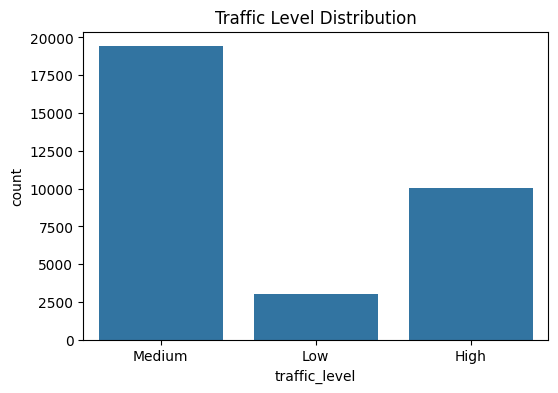

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='traffic_level', data=df)
plt.title("Traffic Level Distribution")
plt.show()

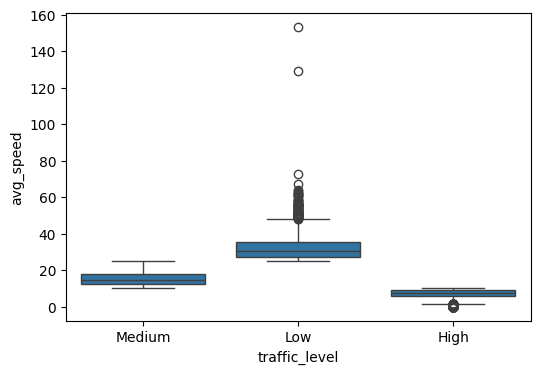

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='traffic_level', y='avg_speed', data=df)
plt.show()

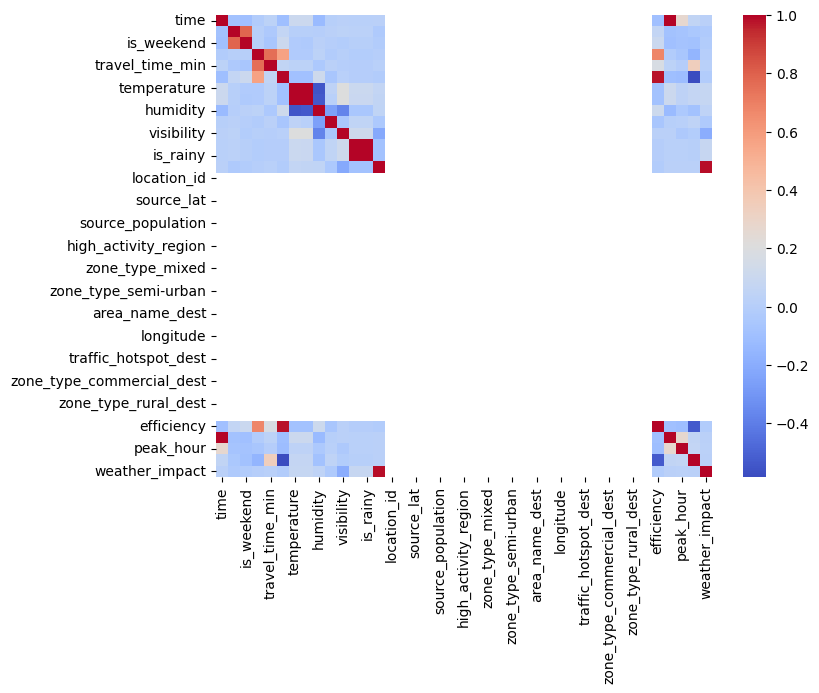

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

In [11]:


# # peak hour
# df['peak_hour'] = df['hour'].apply(lambda x: 1 if (8<=x<=11 or 17<=x<=21) else 0)

# # congestion index
# df['congestion_index'] = df['travel_time_min'] / (df['distance_km'] + 1)

# # efficiency
# df['efficiency'] = df['distance_km'] / (df['travel_time_min'] + 1)

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['traffic_level'] = le.fit_transform(df['traffic_level'])

In [16]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [17]:
features = [
 'distance_km',
 'travel_time_min',
 'avg_speed',
 'road_type',
 'vehicle_type',
 'hour',
 'is_weekend',
 'peak_hour',
 'rainfall',
 'weather_severity',
 'visibility',
 'congestion_index',
 'efficiency'
]

X = df[features]
y = df['traffic_level']

In [18]:
# # Identify categorical features in the 'features' list that require Label Encoding for input
# categorical_features_for_le = ['road_type', 'vehicle_type'] # Based on inspection of 'features' list and df.info()

# # Load a fresh copy of the dataset to get original string values for fitting LabelEncoders
# # This is necessary because 'df' has already had these columns integer-encoded.
# temp_df_for_le = pd.read_csv("transport_dataset.csv")

# le_dict = {}
# for col in categorical_features_for_le:
#     le = LabelEncoder()
#     # Fit the LabelEncoder on the unique original string values for each categorical column
#     le.fit(temp_df_for_le[col].astype(str).unique())
#     le_dict[col] = le

# # After this, the 'le_dict' will contain the fitted encoders
# # for 'road_type' and 'vehicle_type', which 'smart_transport_system' can use.

le_dict = {}

for col in ['road_type','vehicle_type']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

/tmp/ipykernel_9851/3224856380.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))
/tmp/ipykernel_9851/3224856380.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col].astype(str))


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_sm.value_counts())

Before SMOTE:
 traffic_level
2    15513
0     8029
1     2422
Name: count, dtype: int64

After SMOTE:
 traffic_level
2    15513
1    15513
0    15513
Name: count, dtype: int64


In [22]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)

In [23]:
model = RandomForestClassifier(
    n_estimators=80,
    max_depth=10,
    random_state=42
)

model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(max_depth=10, n_estimators=80, random_state=42)

In [24]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       586
           2       1.00      1.00      1.00      3904

    accuracy                           1.00      6491
   macro avg       1.00      1.00      1.00      6491
weighted avg       1.00      1.00      1.00      6491


Confusion Matrix:
 [[2001    0    0]
 [   0  586    0]
 [   0    0 3904]]


In [25]:
joblib.dump(model, "traffic_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_dict, "encoders.pkl")

['encoders.pkl']

In [37]:
label_map = {
    0: " Low Traffic",
    1: " Medium Traffic",
    2: " High Traffic"
}

def get_decision(traffic):
    if "Low" in traffic:
        return " Smooth travel"
    elif "Medium" in traffic:
        return " Moderate traffic"
    else:
        return " Heavy traffic! Avoid"

def suggest_route(source, destination, traffic):
    if "High" in traffic:
        return f"Alternate route via bypass (avoid {source})"
    elif "Medium" in traffic:
        return f"Use secondary roads from {source} to {destination}"
    else:
        return f"Best route: {source} → {destination}"

def estimate_time(distance, traffic):
    speed = 50 if "Low" in traffic else 30 if "Medium" in traffic else 15
    return f"{int((distance/speed)*60)} mins approx"

In [39]:
def smart_transport_system(input_data):

    input_df = pd.DataFrame([input_data])

    input_df['peak_hour'] = input_df['hour'].apply(lambda x: 1 if (8<=x<=11 or 17<=x<=21) else 0)
    input_df['congestion_index'] = input_df['travel_time_min'] / (input_df['distance_km'] + 1)
    input_df['efficiency'] = input_df['distance_km'] / (input_df['travel_time_min'] + 1)

    # Encoding
    for col in le_dict:
        input_df[col] = le_dict[col].transform(input_df[col])

    input_df = input_df[features]

    input_scaled = scaler.transform(input_df)

    # Prediction
    pred = model.predict(input_scaled)[0]

    traffic_label = label_map[pred]  # Convert integer prediction to string label

    route = suggest_route(input_data['source'], input_data['destination'], traffic_label)
    time_readable = estimate_time(input_data['distance_km'], traffic_label)
    decision = get_decision(traffic_label)

    print("\n🚦 SMART TRANSPORT RESULT 🚦\n")
    print("Traffic Level :", traffic_label)
    print("Best Route    :", route)
    print("Estimated Time:", time_readable)
    print("Decision      :", decision)

In [40]:
sample = {
 'distance_km': 40,
 'travel_time_min': 80,
 'avg_speed': 20,
 'road_type': 'city',
 'vehicle_type': 'car',
 'hour': 20,
 'is_weekend': 0,
 'rainfall': 0,
 'weather_severity': 2,
 'visibility': 30,
 'population_density': 8000,
 'traffic_hotspot': 1,
 'source': 'AreaA',
 'destination': 'AreaB'
}

smart_transport_system(sample)


🚦 SMART TRANSPORT RESULT 🚦

Traffic Level :  High Traffic
Best Route    : Alternate route via bypass (avoid AreaA)
Estimated Time: 160 mins approx
Decision      :  Heavy traffic! Avoid


,date,time,day_of_week,is_weekend,source,destination,distance_km,travel_time_min,avg_speed,road_type,...,zone_type_commercial_dest,zone_type_mixed_dest,zone_type_rural_dest,zone_type_semi-urban_dest,efficiency,hour,peak_hour,congestion_index,weather_impact,datetime
0,2016-03-18,17,4,0,"40.7359,-73.9825","40.7739,-73.8707",10.321569,29.866667,20.735295,city,...,NaN,NaN,NaN,NaN,0.334392,17,1,2.638032,NaN,2016-03-18 17:00:00
1,2016-06-04,23,5,1,"40.8026,-73.9338","40.7426,-73.9921",8.283322,22.266667,22.320329,city,...,NaN,NaN,NaN,NaN,0.356017,23,0,2.398567,2.0,2016-06-04 23:00:00
2,2016-01-03,19,6,1,"40.7677,-73.962","40.773,-73.9586",0.655204,2.050000,19.176704,city,...,NaN,NaN,NaN,NaN,0.214821,19,1,1.238518,2.0,2016-01-03 19:00:00
3,2016-05-17,0,1,0,"40.7332,-73.9865","40.744,-73.9796",1.334214,3.150000,25.413598,city,...,NaN,NaN,NaN,NaN,0.321497,0,0,1.349491,1.0,2016-05-17 00:00:00
4,2016-02-10,17,2,0,"40.7973,-73.9723","40.7824,-73.9825",1.866113,48.516667,2.307800,city,...,NaN,NaN,NaN,NaN,0.037687,17,1,16.927689,1.0,2016-02-10 17:00:00
